## <u>Import Libraries</u>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

---
## <u>Load Dataset</u>

This is a **multiclass classification** problem — the label column `Class` has 7 possible categories (types of date fruit), not just 2. That changes a few downstream choices vs regression: we'll need `LabelEncoder` on the target, `CrossEntropyLoss` instead of `MSELoss`, and no `.view(-1,1)` on our y tensors.

In [2]:
data = pd.read_csv("DateFruit_Dataset.csv")
data.isnull().sum() # no null values
data.shape # 898 rows, 34 features, 1 label column
data["Class"].nunique() # 7 different categories in the label column
data.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


---
## <u>Encode Labels</u>

`Class` currently holds text category names (e.g. `"SAFAVI"`, `"DOKOL"`). Neural nets (and `CrossEntropyLoss` specifically) only work with numbers, so `LabelEncoder` maps each unique class name to an integer `0` through `6`. This mapping is what makes our output layer's 7 neurons correspond to real classes later — neuron index 0 = whichever class got encoded as 0, and so on.

In [3]:
le = LabelEncoder()
data["Class"] = le.fit_transform(data["Class"])

---
## <u>Train Test Split</u>

In [4]:
X = data.drop(columns = ["Class"])
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)
type(y_train) # pandas Series -- still needs .values later when converting to a tensor

pandas.core.series.Series

---
## <u>Scaling</u>

Only `X` gets scaled here. `y` is a set of category labels (0-6), not a continuous quantity — scaling a label would be meaningless, so it's left untouched.

In [5]:
scaler = StandardScaler()
scaler.set_output(transform = "pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## <u>Converting into Tensors</u>

Same `.values` rule as always: anything still wrapped in a pandas DataFrame/Series (both `X_train_scaled` and `y_train` here) needs `.values` stripped off before `torch.tensor()` — this applies regardless of whether the object is 1D or 2D.

Two things specific to **multiclass classification**, different from regression:
- `CrossEntropyLoss` expects the target labels in `torch.long` dtype (integer class indices), not `float32`.
- We do **not** call `.view(-1,1)` on `y` here. `CrossEntropyLoss` expects labels in shape `(n,)` — a flat list of class indices — because it internally compares each index against a `(n, num_classes)` prediction matrix. Reshaping to `(n,1)` (like we did for regression) would break that.

In [6]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype = torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.long)

---
## <u>Making TensorDataset and DataLoader</u>

Same chain as regression: `TensorDataset` pairs each `X` row with its matching `y` label so they can be retrieved together, then `DataLoader` wraps that into shuffled mini-batches for training. Test data is never shuffled — order doesn't matter for evaluation.

In [7]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False) # fixed: was pointing at train_dataset

---
## <u>Architecture Design</u>

- The dataset isn't too big, so we choose 1-2 hidden layers only.
- Input layer = 34 neurons, one per feature/column in our dataset.
- Hidden layer neuron counts are generally chosen as a power of 2 (2^n), then adjusted up/down based on performance.
- Output layer = 7 neurons, one per class label.

Layout: `34 (input) → 64 (hidden 1) → 64 (hidden 2) → 7 (output)`

---
## <u>Define Model</u>

When using `CrossEntropyLoss`, the loss/gradient calculation applies softmax internally on its own — so the output layer of a multiclass model should **not** apply softmax explicitly, or you'd effectively be applying it twice.

We only apply softmax explicitly in two cases:
1. When we want the actual class probabilities (not raw logits) — e.g. for displaying confidence scores.
2. When we aren't using `CrossEntropyLoss` at all.

In [8]:
class ANN(nn.Module):

    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # hidden layer 1
            nn.Linear(X_train_tensor.shape[1], 64), # input features = 34
            nn.ReLU(),

            # hidden layer 2
            nn.Linear(64, 64),
            nn.ReLU(),

            # output layer (no softmax needed, CrossEntropyLoss applies it internally)
            nn.Linear(64, 7)
        )

    def forward(self, x):
        return self.model(x)

---
## <u>Compile Model and Define Loss Function</u>

In [9]:
model = ANN()

loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

---
## <u>Train Model</u>

A couple of deliberate differences from the regression training loop:
- **No validation loop here** — the dataset is small (898 rows total), so a validation split wasn't carved out.
- **No "best model" checkpointing** — since we're not tracking validation loss per epoch, there's no signal to compare epochs against, so we just keep whatever weights exist after the final (100th) epoch rather than saving the best one along the way.

In [11]:
epochs = 100
train_loss_history = []
val_loss_history = []
best_val_loss = float("inf") 

for epoch in range(epochs):

    model.train() # 1. go into training mode
    total_train_loss = 0.0 # loss for this epoch

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad() # reset previous batch's gradients

        y_pred = model(batch_X) # raw logits, shape (batch_size, 7)
        batch_loss = loss_func(y_pred, batch_y) # predicted logits, true class indices
        batch_loss.backward() # backpropagation
        optimizer.step()

        total_train_loss = total_train_loss + batch_loss.item()

    avg_train_loss = total_train_loss / len(train_loader) # avg loss per batch, this epoch
    train_loss_history.append(avg_train_loss)

    # validation
    model.eval() # 1. put the model into eval mode
    total_val_loss = 0.0

    with torch.no_grad(): # no gradients needed during validation
        for batch_X, batch_y in test_loader:
            y_pred = model(batch_X)
            batch_loss = loss_func(y_pred, batch_y)
            total_val_loss = total_val_loss + batch_loss.item()

    avg_val_loss = total_val_loss / len(test_loader)
    val_loss_history.append(avg_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {avg_train_loss} & val loss = {avg_val_loss}")

    # Saving the best performing model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model_classification.pt")

epoch 1/100 ==> train loss = 1.0906266129535178 & val loss = 0.8643562297026316
epoch 2/100 ==> train loss = 0.7581319731214772 & val loss = 0.6120527237653732
epoch 3/100 ==> train loss = 0.5659521571967913 & val loss = 0.4818365474541982
epoch 4/100 ==> train loss = 0.45244662787603296 & val loss = 0.39116010814905167
epoch 5/100 ==> train loss = 0.3910036598858626 & val loss = 0.34643880029519397
epoch 6/100 ==> train loss = 0.3542075118292933 & val loss = 0.3255068436264992
epoch 7/100 ==> train loss = 0.3297611002040946 & val loss = 0.31045520802338916
epoch 8/100 ==> train loss = 0.2945721875066343 & val loss = 0.2798989589015643
epoch 9/100 ==> train loss = 0.2850363384122434 & val loss = 0.25539565086364746
epoch 10/100 ==> train loss = 0.26535558182260266 & val loss = 0.25778400525450706
epoch 11/100 ==> train loss = 0.2511232508265454 & val loss = 0.2425983933111032
epoch 12/100 ==> train loss = 0.233262966832389 & val loss = 0.21270496025681496
epoch 13/100 ==> train loss = 

---
## <u>Visualise</u>

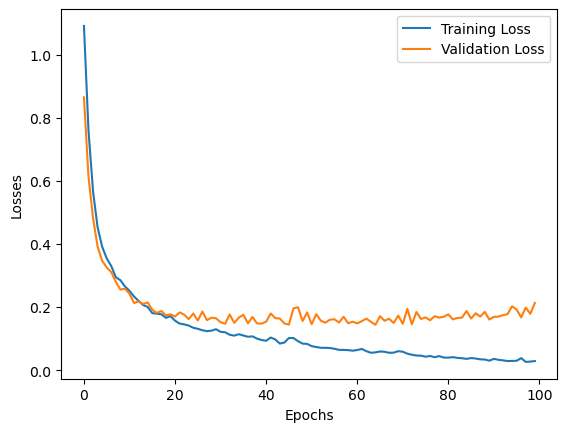

In [12]:
loss_df = pd.DataFrame({
    "Training Loss": train_loss_history,
    "Validation Loss": val_loss_history
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()
plt.show()

#### Finding:

- overfitting starts around epoches 15 to 20, therefore our best model will have the parameters of a model in epoch 15 to 20

---
## <u>Evaluate — small dataset (direct, single-pass method)</u>

Since our whole test set easily fits through the model in one forward pass (only ~180 rows), we can skip batching entirely for evaluation and just feed `X_test_tensor` through directly. This is the simpler method, and it's fine as long as the dataset is small enough to fit in memory in one go.

- `torch.argmax(y_test_pred, dim=1)` converts each row's 7 raw logits into a single predicted class index (0-6) — the index of the highest-scoring logit.
- sklearn's metrics (`accuracy_score`, `precision_score`, etc.) need plain NumPy arrays, so predictions/labels are converted with `.numpy()`.
- `average='weighted'` combines the 7 per-class precision/recall/F1 scores into one number, weighted by how many samples each class has — worth checking `data["Class"].value_counts()` to see if the classes are balanced, which affects whether `'weighted'` or `'macro'` is the more honest choice.

In [13]:
# Loading the best model first
model.load_state_dict(torch.load("best_model_classification.pt", weights_only=True))

model.eval()

with torch.no_grad():
    y_train_pred = model(X_train_tensor) # raw logits, shape (n, 7)
    y_test_pred = model(X_test_tensor)   # raw logits, shape (n, 7)

    train_cross_entropy_loss = loss_func(y_train_pred, y_train_tensor)
    test_cross_entropy_loss = loss_func(y_test_pred, y_test_tensor)

    # convert logits -> predicted class index (highest score per row)
    y_test_pred_classes = torch.argmax(y_test_pred, dim=1)

    accuracy = accuracy_score(y_test_tensor.numpy(), y_test_pred_classes.numpy())
    precision = precision_score(y_test_tensor.numpy(), y_test_pred_classes.numpy(), average='weighted')
    F1_Score = f1_score(y_test_tensor.numpy(), y_test_pred_classes.numpy(), average='weighted')
    recall = recall_score(y_test_tensor.numpy(), y_test_pred_classes.numpy(), average='weighted')

print("Training CE Loss:", train_cross_entropy_loss.item())
print("Testing CE Loss:", test_cross_entropy_loss.item())
print("Accuracy:", accuracy)
print("Precision:", precision)
print("F1 score:", F1_Score)
print("Recall:", recall)

Training CE Loss: 0.05301452800631523
Testing CE Loss: 0.15084783732891083
Accuracy: 0.95
Precision: 0.951192523793143
F1 score: 0.9499279526614869
Recall: 0.95


---
## <u>Evaluate — large-scale (batch-based method)</u>

The method above sends the **entire** test set through the model in a single forward pass. That's fine for 898 rows, but breaks down once a dataset is too large to fit through the model (or into memory) all at once — common with image datasets, or anything with millions of rows. The fix is to evaluate the same way we trained: **in batches**, via `test_loader`, then combine the results afterward.

Step by step, here's what's actually happening and why:

1. **`all_preds`, `all_labels`, `all_logits = []`** — empty lists set up before the loop starts. We can't compute a single accuracy/precision/F1 score per batch and average them naively (a batch of 32 isn't representative of the full 7-class distribution), so instead we collect every batch's results first, and calculate metrics once at the very end on the complete set.

2. **`with torch.no_grad():`** — same as before, no gradients needed since we're only evaluating, not training.

3. **`for xb, yb in test_loader:`** — iterates the test set 32 rows at a time, exactly like the training loop did — this is what makes it scale to any dataset size.

4. **`outputs = model(xb)`** — raw logits for just this batch, shape `(32, 7)` (or smaller for the last batch).

5. **`predicted_classes = torch.argmax(outputs, dim=1)`** — same conversion as before (raw logits → predicted class index), just done per-batch instead of on the whole test set at once.

6. **`all_logits.append(outputs)` / `all_preds.append(predicted_classes)` / `all_labels.append(yb)`** — instead of overwriting these variables every loop iteration (which would leave you with only the *last* batch's results once the loop ends — a real and easy-to-miss bug), each batch's results get appended to a running list.

7. **`torch.cat(all_logits)`** (and same for `all_preds`, `all_labels`) — after the loop finishes, these lists hold one tensor per batch (e.g. 29 separate tensors). `torch.cat()` stitches them back together end-to-end into a single tensor covering the whole test set — as if we'd never split it into batches at all.

8. **Metrics computed once, after the loop** — `loss_func` needs the full-set raw logits `(n, 7)` plus integer labels `(n,)`; the sklearn metrics need the full-set predicted classes `(n,)` plus true labels `(n,)`. Both are now available as single, complete tensors.

In [14]:
all_preds = []
all_labels = []
all_logits = []

model.eval()
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X) # raw logits, shape (batch_size, 7)
        predicted_classes = torch.argmax(outputs, dim=1)

        all_logits.append(outputs)
        all_preds.append(predicted_classes)
        all_labels.append(batch_y)

# stitch all batches back into one tensor each, covering the full test set
all_logits = torch.cat(all_logits)
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# now compute every metric ONCE, on the full test set
test_loss = loss_func(all_logits, all_labels).item()
accuracy = accuracy_score(all_labels.numpy(), all_preds.numpy())
precision = precision_score(all_labels.numpy(), all_preds.numpy(), average='weighted')
f1 = f1_score(all_labels.numpy(), all_preds.numpy(), average='weighted')
recall = recall_score(all_labels.numpy(), all_preds.numpy(), average='weighted')

print("Test Loss:", test_loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("F1 Score:", f1)
print("Recall:", recall)

Test Loss: 0.15084783732891083
Accuracy: 0.95
Precision: 0.951192523793143
F1 Score: 0.9499279526614869
Recall: 0.95
